# Compare 3 Models on Skin Cancer (ISIC) — 4-Class Classification

**VGG19, ResNet18, ResNet50** — all trained on the *same* 4 classes, one after another, in this one notebook.

What it does:
- Downloads the dataset **directly into Colab** via `kagglehub` (no `kaggle.json` file to download — you'll paste your Kaggle username + API key once when prompted).
- Picks **4 classes** (edit `SELECTED_CLASSES` below if you want specific ones).
- Loops through all 3 models, trains each one, and evaluates it.
- Prints one final **comparison table** with Accuracy, Precision, Recall, F1-Score, AUC for all 3 models, plus a bar chart.

Set Colab's runtime to **GPU** first: `Runtime > Change runtime type > T4 GPU`.

⚠️ This will take a while since it trains 3 models back to back — just let it run.

In [ ]:
!pip install -q kagglehub scikit-learn seaborn

## 1. Download dataset via kagglehub
First run will ask you to authenticate. Go to https://www.kaggle.com/settings -> **API** -> **Create New Token** — copy-paste the username and key it shows you. No file download needed.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer9-classesisic


## 2. Find the class folders and select 4 classes

In [ ]:
import os, glob

candidate_dirs = [d for d in glob.glob(os.path.join(path, '**'), recursive=True) if os.path.isdir(d)]
class_dir, all_classes = None, []
for d in sorted(candidate_dirs, key=lambda x: x.count(os.sep)):
    subdirs = sorted([s for s in os.listdir(d) if os.path.isdir(os.path.join(d, s))])
    if len(subdirs) >= 4:
        class_dir, all_classes = d, subdirs
        break

print("Class folder:", class_dir)
print("All classes found:", all_classes)

# ---- EDIT THIS LIST if you want specific classes ----
SELECTED_CLASSES = all_classes[:4]
print("\nSelected classes for training:", SELECTED_CLASSES)

Class folder: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test
All classes found: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Selected classes for training: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma']


In [ ]:
import shutil

filtered_dir = "/content/filtered_dataset"
if os.path.exists(filtered_dir):
    shutil.rmtree(filtered_dir)
os.makedirs(filtered_dir)

for cls in SELECTED_CLASSES:
    os.symlink(os.path.join(class_dir, cls), os.path.join(filtered_dir, cls))

print("Filtered 4-class dataset ready at:", filtered_dir)

Filtered 4-class dataset ready at: /content/filtered_dataset


## 3. Build datasets & dataloaders (shared by all 5 models)
224x224 works fine for all five architectures, so we only need to build this once.

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(filtered_dir, transform=transform)
class_names = full_dataset.classes
print("Class-to-index mapping:", full_dataset.class_to_idx)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Class-to-index mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3}
Train: 44  Val: 9  Test: 11
Using device: cuda


## 4. Model builder — one function that returns any of the 5 models

In [ ]:
import torch.nn as nn
from torchvision import models

def build_model(name, num_classes):
    if name == "AlexNet":
        m = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(4096, num_classes)
    elif name == "VGG16":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(4096, num_classes)
    elif name == "VGG19":
        m = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(4096, num_classes)
    elif name == "ResNet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "ResNet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m.to(device)

MODEL_NAMES = ["VGG19", "ResNet18", "ResNet50"]
EPOCHS = 10

## 5. Train + evaluate function (runs for one model at a time)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

def run_epoch(model, loader, criterion, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def train_and_evaluate(name):
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    model = build_model(name, len(class_names))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, train=False)
        print(f"[{name}] Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # Evaluate on test set
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
    try:
        auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr') * 100
    except Exception as e:
        auc = float('nan')
        print("AUC could not be computed:", e)

    print(f"\n---- {name} Test Results ----")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%")
    print(f"AUC       : {auc:.2f}%")

    # free GPU memory before the next model
    del model
    torch.cuda.empty_cache()

    return {"Model": name, "Accuracy (%)": acc, "Precision (%)": prec,
            "Recall (%)": rec, "F1-Score (%)": f1, "AUC (%)": auc}

## 6. Run all 3 models, one after another

In [ ]:
results = []
for name in MODEL_NAMES:
    results.append(train_and_evaluate(name))

print("\nAll 3 models done.")


Training VGG19
[VGG19] Epoch 1/10  train_loss=1.4182 train_acc=0.2727  val_loss=1.1384 val_acc=0.7778
[VGG19] Epoch 2/10  train_loss=1.1529 train_acc=0.4773  val_loss=0.8305 val_acc=0.7778
[VGG19] Epoch 3/10  train_loss=0.8165 train_acc=0.7500  val_loss=0.7687 val_acc=0.7778
[VGG19] Epoch 4/10  train_loss=0.4135 train_acc=0.8409  val_loss=0.3813 val_acc=0.7778
[VGG19] Epoch 5/10  train_loss=0.1511 train_acc=0.9773  val_loss=0.4689 val_acc=0.7778
[VGG19] Epoch 6/10  train_loss=0.1744 train_acc=0.9545  val_loss=1.6198 val_acc=0.6667
[VGG19] Epoch 7/10  train_loss=0.1580 train_acc=0.9318  val_loss=0.7796 val_acc=0.7778
[VGG19] Epoch 8/10  train_loss=0.3750 train_acc=0.8864  val_loss=0.2243 val_acc=0.8889
[VGG19] Epoch 9/10  train_loss=0.0057 train_acc=1.0000  val_loss=1.2915 val_acc=0.5556
[VGG19] Epoch 10/10  train_loss=0.1738 train_acc=0.9318  val_loss=0.5693 val_acc=0.5556

---- VGG19 Test Results ----
Accuracy  : 72.73%
Precision : 83.75%
Recall    : 77.08%
F1-Score  : 75.60%
AUC    

## 7. Final comparison table

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).set_index("Model").round(2)
results_df

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
Model,,,,,
VGG19,72.73,83.75,77.08,75.60,94.49
ResNet18,81.82,90.00,87.50,85.42,89.73
ResNet50,63.64,72.50,72.92,70.83,86.61


## 8. (Optional) Bar chart comparing all 3 models

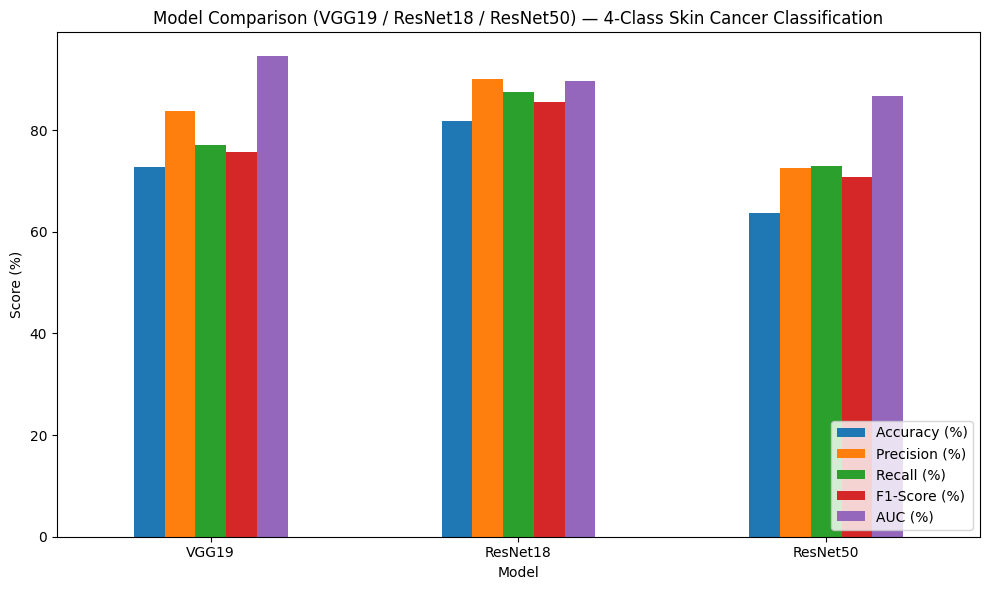

In [ ]:
import matplotlib.pyplot as plt

results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison (VGG19 / ResNet18 / ResNet50) — 4-Class Skin Cancer Classification")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()